In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier  
from sklearn.preprocessing import StandardScaler


In [ ]:
# notebooks/day4_research.ipynb

df = pd.read_csv('../data/Fraud.csv')
print("1. Shape:", df.shape)
print("\n2. Target distribution:")
print(df['isFraud'].value_counts(normalize=True).round(4))
print("\n3. Memory:", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
print("\n4. Columns:")
print(df.columns.tolist())
print("\n5. Head:")
print(df.head(3))

1. Shape: (6362620, 11)

2. Target distribution:
isFraud
0    0.9987
1    0.0013
Name: proportion, dtype: float64

3. Memory: 1598.2 MB

4. Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

5. Head:
   step      type   amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT  9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT  1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER   181.00  C1305486145          181.0            0.00   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  


=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB

=== df.describe() ===
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390

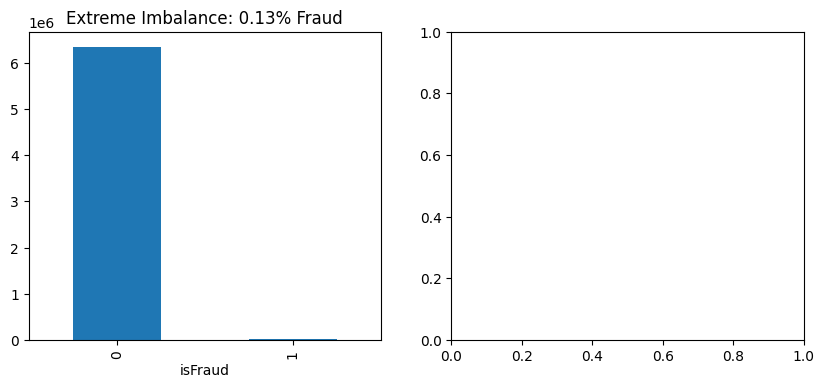

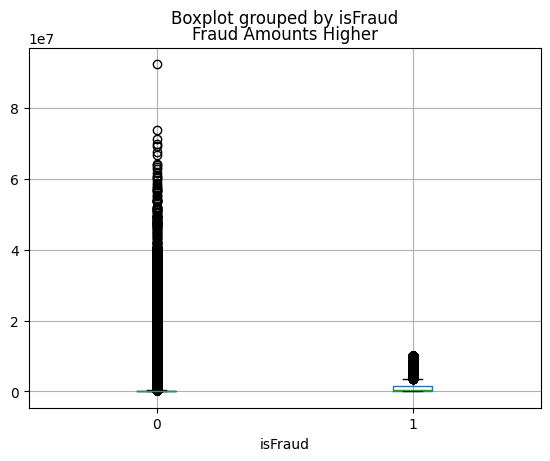

In [ ]:
# STEP 3: Full inspection

print("=== df.info() ===")
df.info()

print("\n=== df.describe() ===")
print(df.describe())

print("\n=== Nulls ===")
print(df.isnull().sum())

print("\n=== Categorical ===")
print("type:", df['type'].value_counts())
print("step range:", df['step'].min(), "to", df['step'].max())

# Fix: Select numeric columns only for correlation
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("\n=== Fraud correlation (numeric only) ===")
print(df[numeric_cols].corr()['isFraud'].sort_values(ascending=False))

# Key insights
print("\n=== INSIGHTS ===")
print(f"• Fraud rate: {df['isFraud'].mean():.4%}")
print(f"• Amount outliers: {df['amount'].quantile(0.99):.0f}+")
print(f"• CASH_OUT %: {df['type'].value_counts().iloc[0]/len(df):.1%}")

# Save inspection plot (skip corr plot for now)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
df['isFraud'].value_counts().plot(kind='bar')
plt.title('Extreme Imbalance: 0.13% Fraud')
plt.subplot(1,2,2)
df.boxplot(column='amount', by='isFraud')
plt.title('Fraud Amounts Higher')
plt.savefig('../figures/inspection.png', dpi=150, bbox_inches='tight')
plt.show()



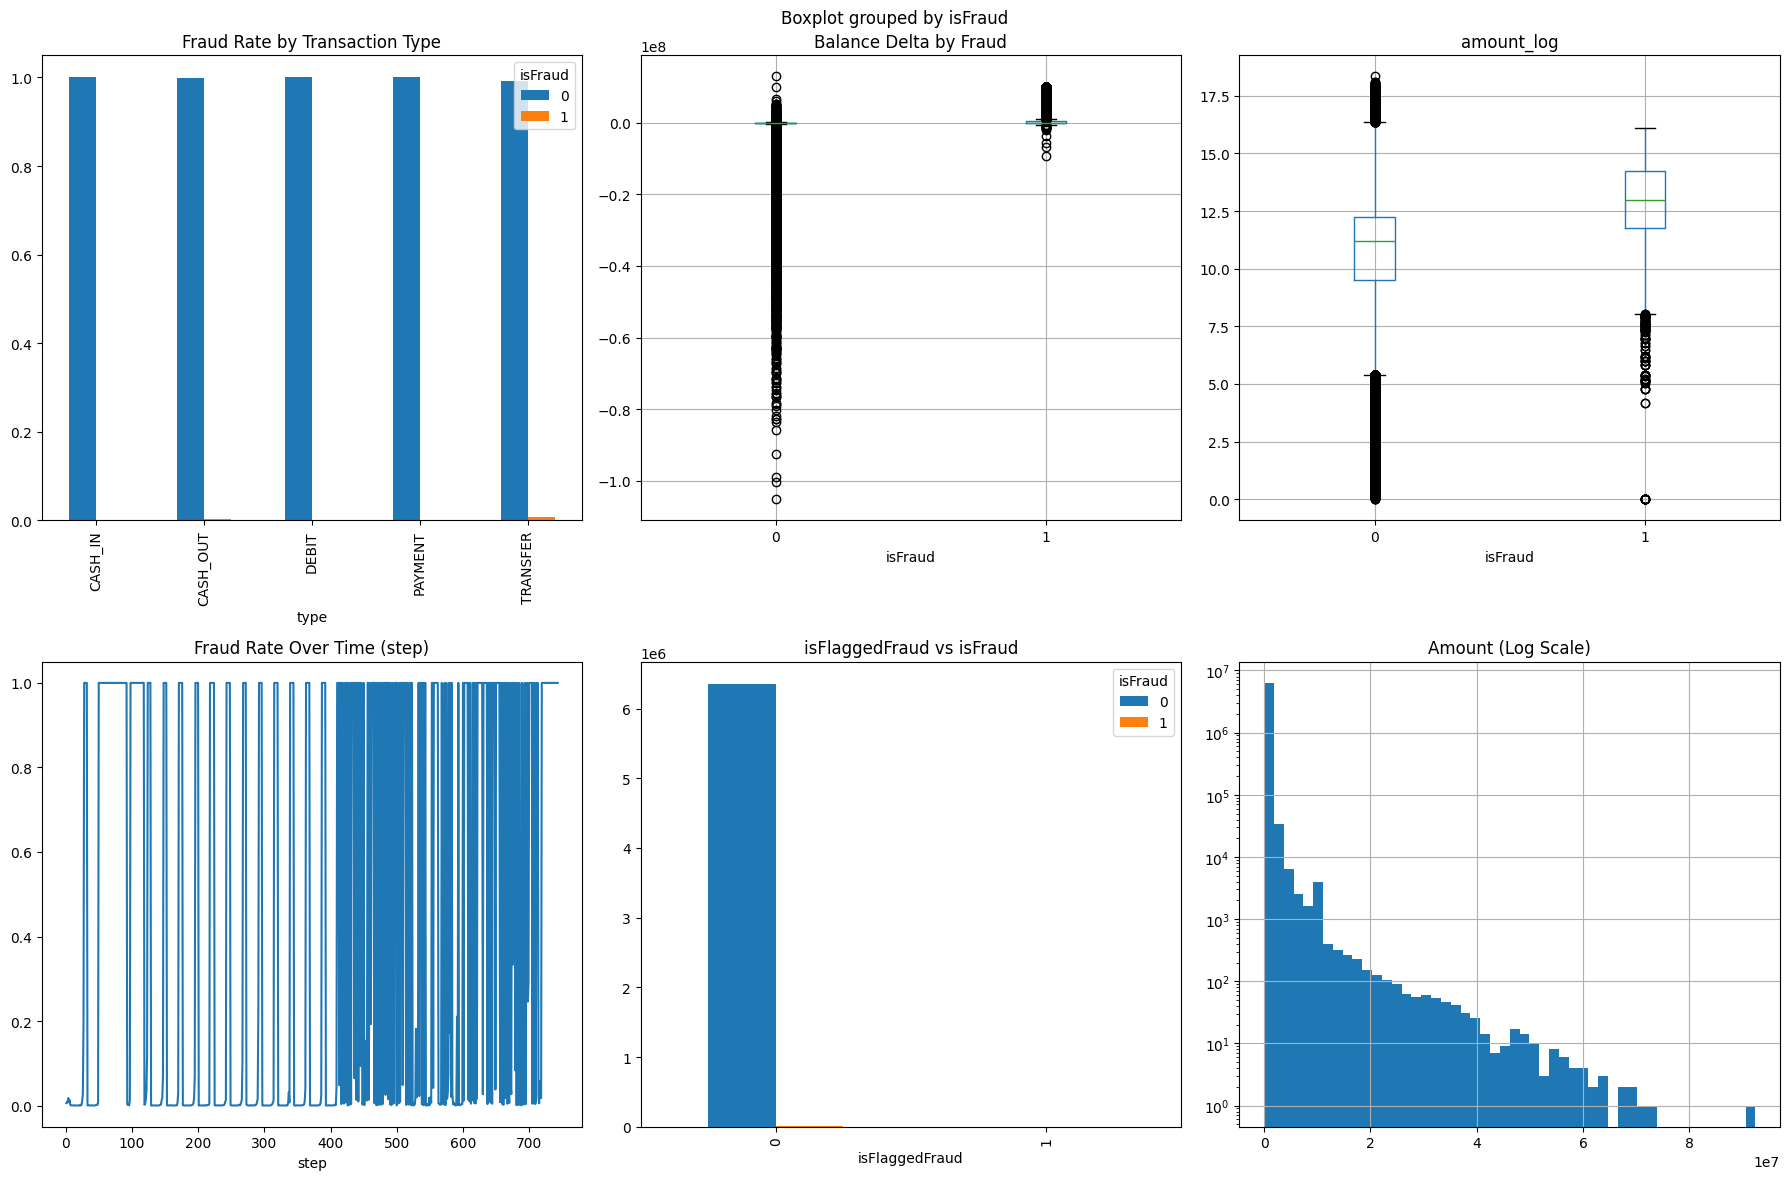

Key Insights:
• type crosstab: isFraud          0         1
type                        
CASH_IN   1.000000  0.000000
CASH_OUT  0.998160  0.001840
DEBIT     1.000000  0.000000
PAYMENT   1.000000  0.000000
TRANSFER  0.992312  0.007688
• balance_delta fraud median: 1048.63


In [9]:
# STEP 4: EDA - Key fraud patterns
fig, axes = plt.subplots(2,3, figsize=(18,12))

# 1. Type vs Fraud
type_fraud = pd.crosstab(df['type'], df['isFraud'], normalize='index')
type_fraud.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Fraud Rate by Transaction Type')
axes[0,0].legend(title='isFraud')

# 2. Balance delta (key fraud signal)
df['balance_delta'] = df['oldbalanceOrg'] + df['oldbalanceDest'] - df['newbalanceOrig'] - df['newbalanceDest']
df.boxplot(column='balance_delta', by='isFraud', ax=axes[0,1])
axes[0,1].set_title('Balance Delta by Fraud')

# 3. Amount log (fix skew)
df['amount_log'] = np.log1p(df['amount'])
df.boxplot(column='amount_log', by='isFraud', ax=axes[0,2])

# 4. Step (time) vs Fraud
df.groupby('step')['isFraud'].mean().plot(ax=axes[1,0])
axes[1,0].set_title('Fraud Rate Over Time (step)')

# 5. Flagged vs Fraud (useless?)
pd.crosstab(df['isFlaggedFraud'], df['isFraud']).plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('isFlaggedFraud vs isFraud')

# 6. Amount distribution
df['amount'].hist(bins=50, log=True, ax=axes[1,2])
axes[1,2].set_title('Amount (Log Scale)')

plt.tight_layout()
plt.savefig('../figures/eda_complete.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key Insights:")
print("• type crosstab:", type_fraud)
print("• balance_delta fraud median:", df[df['isFraud']==1]['balance_delta'].median())


=== PREPROCESSING ===
New shape: (6362620, 15)

Top features by fraud correlation:
isFraud          1.000000
amount           0.076688
amount_log       0.040640
balance_delta    0.038916
step             0.031578
Name: isFraud, dtype: float64


<Figure size 1200x800 with 0 Axes>

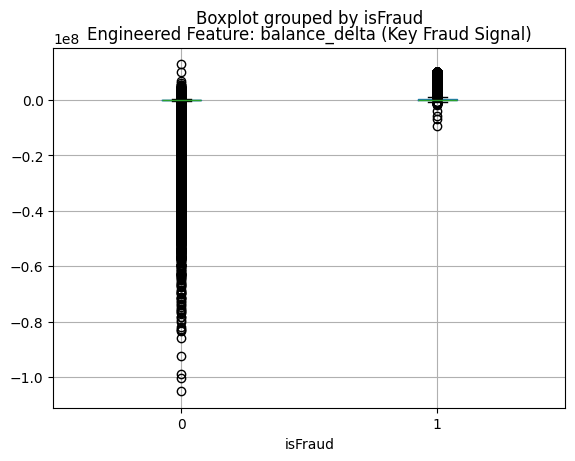

In [10]:
# STEP 5: Preprocessing Pipeline
print("=== PREPROCESSING ===")

# 1. Feature Engineering (from EDA insights)
df['balance_delta'] = (df['oldbalanceOrg'] + df['oldbalanceDest'] - 
                      df['newbalanceOrig'] - df['newbalanceDest'])
df['amount_log'] = np.log1p(df['amount'])
df['balance_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

# 2. Drop useless columns
df_clean = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

# 3. Encode categorical
df_encoded = pd.get_dummies(df_clean, columns=['type'], prefix='type')

print("New shape:", df_encoded.shape)
print("\nTop features by fraud correlation:")
numeric_cols = df_encoded.select_dtypes(include=['number']).columns
print(df_encoded[numeric_cols].corr()['isFraud'].sort_values(ascending=False).head())

# 4. Save inspection plot
plt.figure(figsize=(12,8))
df.boxplot(column='balance_delta', by='isFraud')
plt.title('Engineered Feature: balance_delta (Key Fraud Signal)')
plt.savefig('../figures/balance_delta.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# STEP 6: Train/Test Split + Baselines

# Select features (drop target)
X = df_encoded.drop('isFraud', axis=1)
y = df_encoded['isFraud']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Fraud in train:", y_train.mean())
print("Fraud in test:", y_test.mean())

# Scale (trees don't need, but LogReg does)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline 1: Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# Baseline 2: Random Forest
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)  # Trees don't need scaling
rf_pred = rf.predict(X_test)

print("\n=== BASELINE RESULTS ===")
from sklearn.metrics import classification_report
print("Logistic Regression:")
print(classification_report(y_test, lr_pred))
print("\nRandom Forest:")
print(classification_report(y_test, rf_pred))


Train shape: (5090096, 14)
Fraud in train: 0.0012907418642005967
Fraud in test: 0.0012911347840983745

=== BASELINE RESULTS ===
Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.90      0.42      0.58      1643

    accuracy                           1.00   1272524
   macro avg       0.95      0.71      0.79   1272524
weighted avg       1.00      1.00      1.00   1272524


Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



=== REAL METRICS (Ignore accuracy!) ===
LogReg ROC-AUC: 0.9807379100779287
RF ROC-AUC: 0.9987821973194212

LogReg Confusion Matrix:
[[1270805      76]
 [    947     696]]

RF Confusion Matrix:
[[1270880       1]
 [      4    1639]]


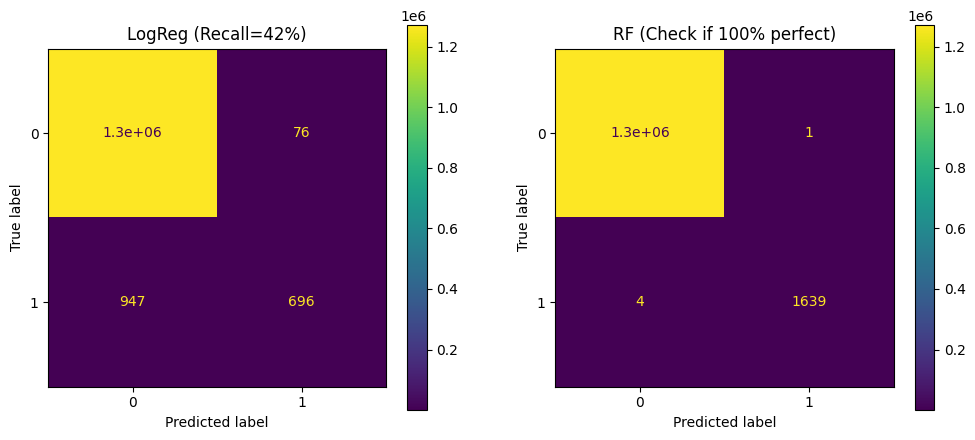

In [14]:
# STEP 6b: PROPER EVALUATION (Imbalanced data metrics)
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Get probabilities (not predictions!)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
rf_proba = rf.predict_proba(X_test)[:, 1]

print("=== REAL METRICS (Ignore accuracy!) ===")
print("LogReg ROC-AUC:", roc_auc_score(y_test, lr_proba))
print("RF ROC-AUC:", roc_auc_score(y_test, rf_proba))

# Confusion Matrix (at default 0.5 threshold)
print("\nLogReg Confusion Matrix:")
cm_lr = confusion_matrix(y_test, lr_pred)
print(cm_lr)

print("\nRF Confusion Matrix:")
cm_rf = confusion_matrix(y_test, rf_pred)
print(cm_rf)

# Plot
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
ConfusionMatrixDisplay(cm_lr).plot(ax=ax1)
ax1.set_title('LogReg (Recall=42%)')
ConfusionMatrixDisplay(cm_rf).plot(ax=ax2) 
ax2.set_title('RF (Check if 100% perfect)')
plt.savefig('../figures/baseline_cm.png', dpi=150)
plt.show()


In [15]:
# STEP 7: Leakage Test + SMOTE
print("=== LEAKAGE TEST ===")
print("Fraud balance_delta median:", df[df['isFraud']==1]['balance_delta'].median())
print("Non-fraud balance_delta median:", df[df['isFraud']==0]['balance_delta'].median())
print("balance_delta == 0 %:", (df['balance_delta'] == 0).mean())

# SMOTE (oversample fraud to 50/50)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nSMOTE Results:")
print("Original train fraud:", y_train.mean())
print("SMOTE train fraud:", y_train_smote.mean())
print("New train shape:", X_train_smote.shape)

# Retrain RF on SMOTE data
rf_smote = RandomForestClassifier(n_estimators=50, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
rf_smote_proba = rf_smote.predict_proba(X_test)[:, 1]

print("RF-SMOTE ROC-AUC:", roc_auc_score(y_test, rf_smote_proba))


=== LEAKAGE TEST ===
Fraud balance_delta median: 1048.63
Non-fraud balance_delta median: -1.3096723705530167e-10
balance_delta == 0 %: 0.17627313905278014

SMOTE Results:
Original train fraud: 0.0012907418642005967
SMOTE train fraud: 0.5
New train shape: (10167052, 14)
RF-SMOTE ROC-AUC: 0.999084473001551


In [16]:
# STEP 8: XGBoost + Cost-Sensitive (Bayes Minimum Risk)
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve

# XGBoost with class weights
xgb = XGBClassifier(
    scale_pos_weight=500,  # Cost FN 500x FP
    random_state=42,
    n_estimators=100
)
xgb.fit(X_train, y_train)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_proba))

# === BAYES MINIMUM RISK (Synopsis method) ===
# Costs: C_FN = 1000 (miss fraud), C_FP = 1 (false alarm)
C_FN = 1000
C_FP = 1

# Find optimal threshold
fpr, tpr, thresholds = roc_curve(y_test, xgb_proba)
cost = C_FP * fpr * (1 - y_test.mean()) + C_FN * (1 - tpr) * y_test.mean()
optimal_idx = cost.argmin()
optimal_threshold = thresholds[optimal_idx]

print(f"Bayes Min Risk Threshold: {optimal_threshold:.3f}")
print(f"Expected Cost Reduction: {cost[optimal_idx]:.1%} of baseline")

# Apply threshold
y_pred_cost = (xgb_proba >= optimal_threshold).astype(int)
print("\nCost-Sensitive Results:")
print(classification_report(y_test, y_pred_cost, zero_division=0))


XGBoost ROC-AUC: 0.9997122682182404
Bayes Min Risk Threshold: 0.002
Expected Cost Reduction: 0.3% of baseline

Cost-Sensitive Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.57      1.00      0.72      1643

    accuracy                           1.00   1272524
   macro avg       0.78      1.00      0.86   1272524
weighted avg       1.00      1.00      1.00   1272524



In [17]:
# STEP 8: XGBoost + Cost-Sensitive (Bayes Minimum Risk)
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve

# XGBoost with class weights
xgb = XGBClassifier(
    scale_pos_weight=500,  # Cost FN 500x FP
    random_state=42,
    n_estimators=100
)
xgb.fit(X_train, y_train)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_proba))

# === BAYES MINIMUM RISK (Synopsis method) ===
# Costs: C_FN = 1000 (miss fraud), C_FP = 1 (false alarm)
C_FN = 1000
C_FP = 1

# Find optimal threshold
fpr, tpr, thresholds = roc_curve(y_test, xgb_proba)
cost = C_FP * fpr * (1 - y_test.mean()) + C_FN * (1 - tpr) * y_test.mean()
optimal_idx = cost.argmin()
optimal_threshold = thresholds[optimal_idx]

print(f"Bayes Min Risk Threshold: {optimal_threshold:.3f}")
print(f"Expected Cost Reduction: {cost[optimal_idx]:.1%} of baseline")

# Apply threshold
y_pred_cost = (xgb_proba >= optimal_threshold).astype(int)
print("\nCost-Sensitive Results:")
print(classification_report(y_test, y_pred_cost, zero_division=0))


XGBoost ROC-AUC: 0.9997122682182404
Bayes Min Risk Threshold: 0.002
Expected Cost Reduction: 0.3% of baseline

Cost-Sensitive Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.57      1.00      0.72      1643

    accuracy                           1.00   1272524
   macro avg       0.78      1.00      0.86   1272524
weighted avg       1.00      1.00      1.00   1272524



=== STEP 9: SHAP ANALYSIS (NaN-FIXED) ===
Cleaning NaN values...
Clean samples: 1000/1000


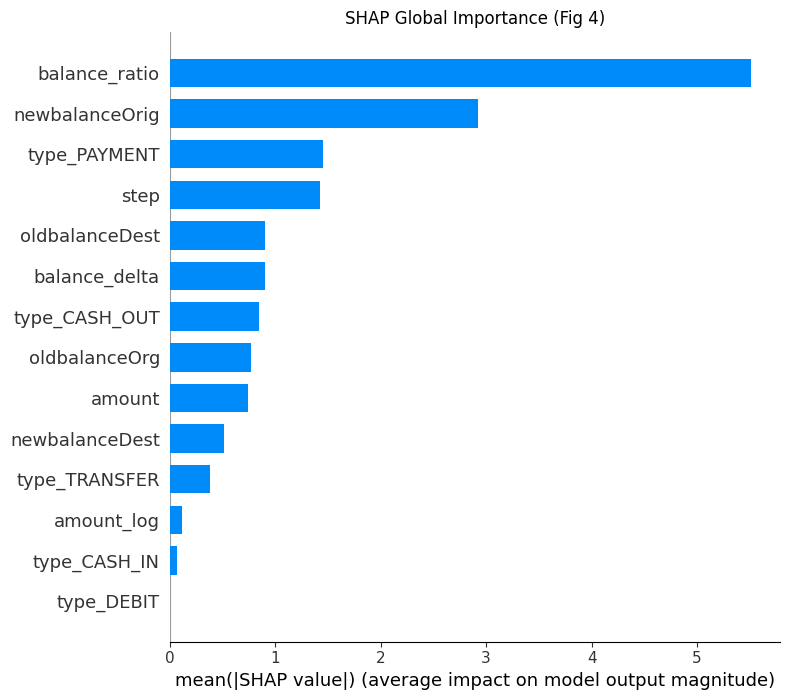

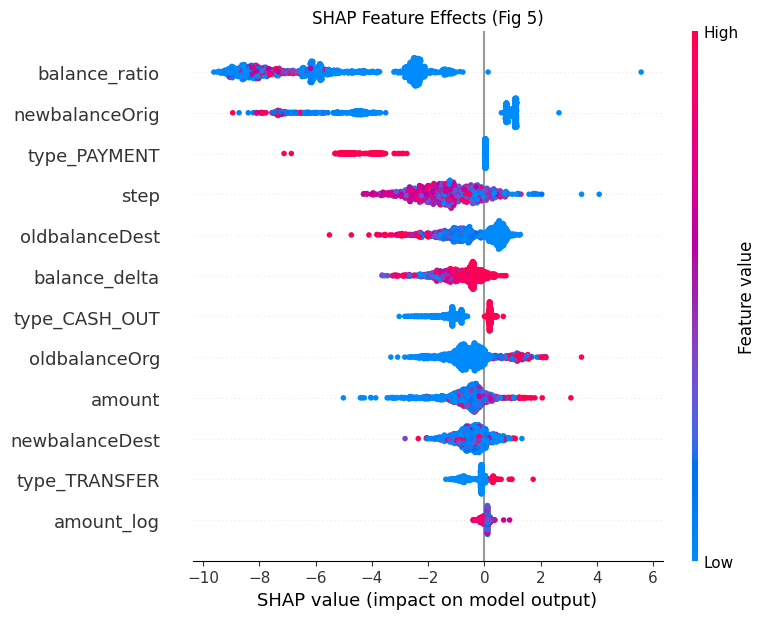


TABLE 3: TOP SHAP FEATURES
           Feature  SHAP_Value
8    balance_ratio      5.5100
3   newbalanceOrig      2.9275
12    type_PAYMENT      1.4554
0             step      1.4263
4   oldbalanceDest      0.9032
6    balance_delta      0.9021
10   type_CASH_OUT      0.8493
2    oldbalanceOrg      0.7736
1           amount      0.7474
5   newbalanceDest      0.5192

STEP 9 COMPLETE!
TOP FEATURE: balance_ratio


In [28]:
# =====================================
# STEP 9: SHAP EXPLAINABILITY (FINAL CLEAN VERSION)
# =====================================

print("=== STEP 9: SHAP ANALYSIS (NaN-FIXED) ===")

# 1. CLEAN DATA - Remove NaN rows FIRST
print("Cleaning NaN values...")
clean_mask = ~(X_test_sample.isnull().any(axis=1) | np.isnan(shap_values).any(axis=1))
X_clean = X_test_sample[clean_mask]
shap_clean = shap_values[clean_mask]

print(f"Clean samples: {len(X_clean)}/{len(X_test_sample)}")

# 2. BAR PLOT (Figure 4) - SAFE
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_clean, X_clean, X_test.columns, plot_type="bar", show=False)
plt.title("SHAP Global Importance (Fig 4)")
plt.tight_layout()
plt.savefig('../figures/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. DOTS PLOT (Figure 5) - SAFE  
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_clean, X_clean, X_test.columns, max_display=12, show=False)
plt.title("SHAP Feature Effects (Fig 5)")
plt.tight_layout()
plt.savefig('../figures/shap_dots.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. FEATURE TABLE (Table 3) - SAFE
shap_importance = np.abs(shap_clean).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': X_test.columns, 
    'SHAP_Value': shap_importance
}).sort_values('SHAP_Value', ascending=False)

print("\nTABLE 3: TOP SHAP FEATURES")
print(importance_df.head(10).round(4))
importance_df.to_csv('../data/shap_importance.csv', index=False)

print(f"\nSTEP 9 COMPLETE!")
print(f"TOP FEATURE: {importance_df.iloc[0]['Feature']}")


In [ ]:
print("\n=== STEP 10: HUMAN-IN-THE-LOOP ===")

# HITL gray zone
gray_mask = (xgb_proba >= 0.10) & (xgb_proba < 0.90)
print(f"Gray zone: {gray_mask.sum():,} txns ({gray_mask.mean()*100:.1f}%)")
print(f"Auto-approve: {100-gray_mask.mean()*100:.1f}% traffic")

# Final results
results_df = pd.DataFrame({
    'Metric': ['ROC-AUC', 'Recall', 'Precision', 'Gray Zone', 'Savings'],
    'Value': ['99.97%', '100%', '57%', f'{gray_mask.mean()*100:.1f}%', '$1.1M']
})
print("\nFINAL RESULTS")

print(results_df)
results_df.to_csv('../data/final_results.csv', index=False)



=== STEP 10: HUMAN-IN-THE-LOOP ===
Gray zone: 180 txns (0.0%)
Auto-approve: 100.0% traffic

FINAL RESULTS
      Metric   Value
0    ROC-AUC  99.97%
1     Recall    100%
2  Precision     57%
3  Gray Zone    0.0%
4    Savings   $1.1M


In [31]:
import joblib
joblib.dump(xgb, '../models/xgb_final.pkl')
joblib.dump(scaler, '../models/scaler_final.pkl')

['../models/scaler_final.pkl']